In [14]:
!pip install scikit-learn pandas numpy tensorflow matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# TensorFlow / Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Train Shape: (7613, 5)
Test Shape: (3263, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


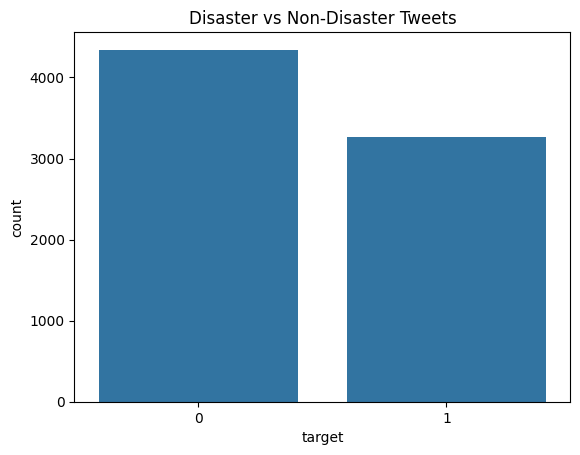

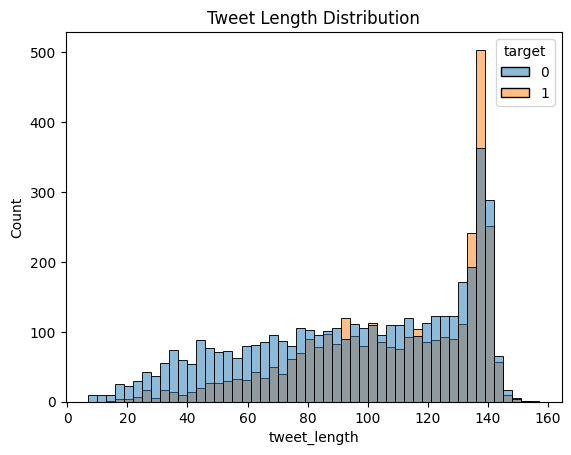

In [15]:
# Load Datasets
train_df = pd.read_csv("/content/drive/MyDrive/Neural network Lab Project/train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Neural network Lab Project/test.csv")

# Dataset Information
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
train_df.info()

# Fill Missing Values
train_df["keyword"] = train_df["keyword"].fillna("")
train_df["location"] = train_df["location"].fillna("")
test_df["keyword"] = test_df["keyword"].fillna("")
test_df["location"] = test_df["location"].fillna("")

# EDA: Class Distribution
sns.countplot(x="target", data=train_df)
plt.title("Disaster vs Non-Disaster Tweets")
plt.show()

# EDA: Tweet Length Distribution
train_df["tweet_length"] = train_df["text"].apply(len)
sns.histplot(data=train_df, x="tweet_length", hue="target", bins=50)
plt.title("Tweet Length Distribution")
plt.show()

In [16]:
# Text Cleaning Function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Apply Cleaning
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

# Prepare Features
X = train_df["clean_text"]
y = train_df["target"]

# Train-Test Split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Tokenization
MAX_WORDS = 20000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert Text To Sequence & Padding
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding="post")
X_valid_pad = pad_sequences(tokenizer.texts_to_sequences(X_valid), maxlen=MAX_LEN, padding="post")
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(test_df["clean_text"]), maxlen=MAX_LEN, padding="post")

# Define Shared Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

In [18]:
# LSTM Model (Tanjina Ahmed Mitu)

lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_WORDS, output_dim=128),
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_model.summary()

# Train Model
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_valid_pad, y_valid),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

# Evaluate Model
pred_prob_lstm = lstm_model.predict(X_valid_pad)
pred_lstm = (pred_prob_lstm > 0.5).astype(int)

print("\nLSTM Classification Report:")
print(classification_report(y_valid, pred_lstm))
print("LSTM Accuracy:", accuracy_score(y_valid, pred_lstm))

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 48s 223ms/step - accuracy: 0.5685 - loss: 0.6849 - val_accuracy: 0.5706 - val_loss: 0.6832
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 33s 172ms/step - accuracy: 0.5703 - loss: 0.6846 - val_accuracy: 0.5706 - val_loss: 0.6838
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.5703 - loss: 0.6841 - val_accuracy: 0.5706 - val_loss: 0.6832
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.57      1.00      0.73       869
           1       0.00      0.00      0.00       654

    accuracy                           0.57      1523
   macro avg       0.29      0.50      0.36      1523
weighted avg       0.33      0.57      0.41      1523

LSTM Accuracy: 0.5705843729481287


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Multi-layer Perceptron (Rifat Jahan)
mlp_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

mlp_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train Model
history_mlp = mlp_model.fit(
    X_train_pad, y_train,
    validation_data=(X_valid_pad, y_valid),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

# Evaluate Model
pred_prob_mlp = mlp_model.predict(X_valid_pad)
pred_mlp = (pred_prob_mlp > 0.5).astype(int)

print("\nMLP Classification Report:")
print(classification_report(y_valid, pred_mlp))
print("MLP Accuracy:", accuracy_score(y_valid, pred_mlp))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.5726 - loss: 0.6773 - val_accuracy: 0.5883 - val_loss: 0.6427
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7519 - loss: 0.5306 - val_accuracy: 0.8043 - val_loss: 0.4531
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8466 - loss: 0.3646 - val_accuracy: 0.7682 - val_loss: 0.5480
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8928 - loss: 0.2847 - val_accuracy: 0.8017 - val_loss: 0.5201
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9140 - loss: 0.2329 - val_accuracy: 0.7951 - val_loss: 0.4953
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

MLP Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.93      0.84       869
           1       0.88      0.63      0.74       654

    accuracy                           0.80      1523
   macro avg       0.82      0.78      0.79      1523
weighted avg       0.82   

In [ ]:
# 1D Convolutional Neural Network(Seyam Bin H Rahman)
cnn_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train Model
history_cnn = cnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_valid_pad, y_valid),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)
cnn_lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

cnn_lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train Model
history_cnn_lstm = cnn_lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_valid_pad, y_valid),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

# Evaluate Model
pred_prob_cnn_lstm = cnn_lstm_model.predict(X_valid_pad)
pred_cnn_lstm = (pred_prob_cnn_lstm > 0.5).astype(int)

print("\nCNN-LSTM Classification Report:")
print(classification_report(y_valid, pred_cnn_lstm))
print("CNN-LSTM Accuracy:", accuracy_score(y_valid, pred_cnn_lstm))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7031 - loss: 0.5627 - val_accuracy: 0.7958 - val_loss: 0.4428
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.8716 - loss: 0.3203 - val_accuracy: 0.8063 - val_loss: 0.4589
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9484 - loss: 0.1578 - val_accuracy: 0.7781 - val_loss: 0.5769
Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.6496 - loss: 0.6316 - val_accuracy: 0.7866 - val_loss: 0.5096
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.8263 - loss: 0.4253 - val_accuracy: 0.7919 - val_loss: 0.4705
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9072 - loss: 0.2729 - val_accuracy: 0.7945 - val_loss: 0.4933
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

CNN-LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.93      0.83       869
           1       0.86      0.60      0.71       6

In [ ]:
# Download and Extract GloVe- Nafia Anjum Khan
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d glove_data

# Read GloVe File
embeddings_index = {}
with open('glove_data/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index)} pre-trained word vectors.")

# Create Embedding Matrix
embedding_dim = 100
word_index = tokenizer.word_index
num_words = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i >= MAX_WORDS:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Build Model
pretrained_model = Sequential([
    Embedding(
        input_dim=num_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

pretrained_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train Model
history_pretrained = pretrained_model.fit(
    X_train_pad, y_train,
    validation_data=(X_valid_pad, y_valid),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

# Evaluate Model
pred_prob_pretrained = pretrained_model.predict(X_valid_pad)
pred_pretrained = (pred_prob_pretrained > 0.5).astype(int)

print("\nGloVe Pre-trained Classification Report:")
print(classification_report(y_valid, pred_pretrained))
print("GloVe Pre-trained Accuracy:", accuracy_score(y_valid, pred_pretrained))

--2026-06-03 05:42:00--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-06-03 05:42:01--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-03 05:42:01--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

FileNotFoundError: [Errno 2] No such file or directory: 'glove_data/glove.6B.100d.txt'

⏳ Evaluating all models...


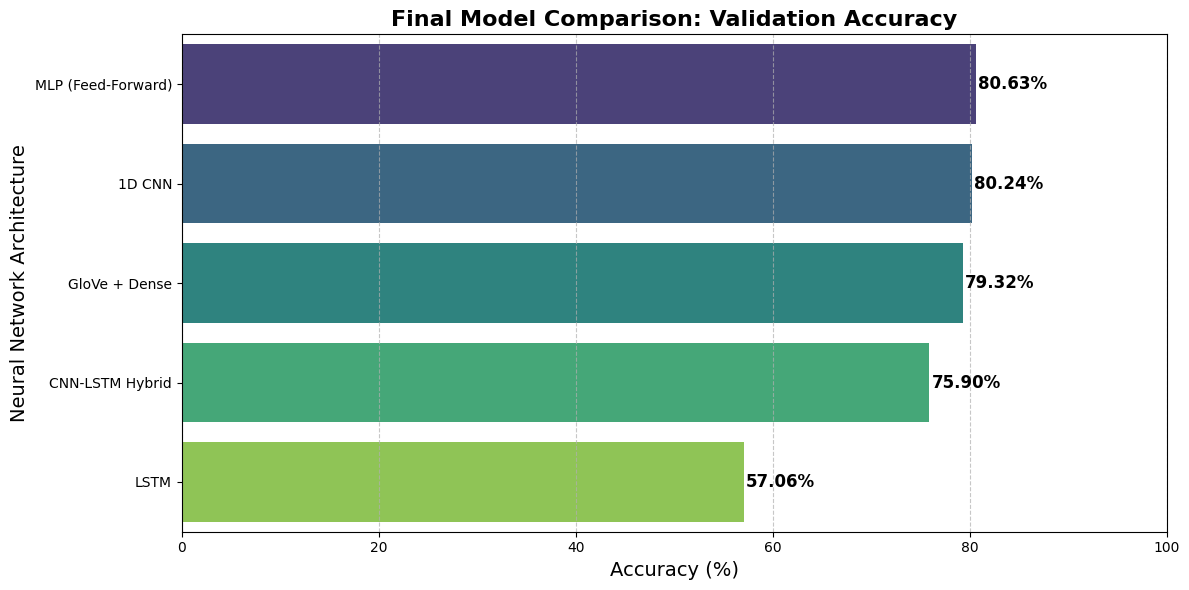

In [ ]:
# Define Model Dictionary
models_dict = {
    "LSTM": lstm_model,
    "MLP (Feed-Forward)": mlp_model,
    "1D CNN": cnn_model,
    "CNN-LSTM Hybrid": cnn_lstm_model,
    "GloVe + Dense": pretrained_model
}

model_names = []
accuracies = []

print("⏳ Evaluating all models...")

# Calculate Final Accuracies
for name, model in models_dict.items():
    pred_prob = model.predict(X_valid_pad, verbose=0)
    predictions = (pred_prob > 0.5).astype(int)
    acc = accuracy_score(y_valid, predictions)

    model_names.append(name)
    accuracies.append(acc * 100)

# Compile to DataFrame
results_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy (%)': accuracies
}).sort_values(by='Accuracy (%)', ascending=False)

# Plot Results
plt.figure(figsize=(12, 6))
barplot = sns.barplot(x='Accuracy (%)', y='Model', data=results_df, hue='Model', palette='viridis', legend=False)

for index, value in enumerate(results_df['Accuracy (%)']):
    plt.text(value + 0.2, index, f'{value:.2f}%', va='center', fontsize=12, fontweight='bold')

plt.title('Final Model Comparison: Validation Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Accuracy (%)', fontsize=14)
plt.ylabel('Neural Network Architecture', fontsize=14)
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()